# 线性回归练习1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
dt = pd.read_csv('ex1data1.txt',header = None,names = ['人口','利润'])

In [5]:
dt.head()

,人口,利润
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [6]:
 dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   人口      97 non-null     float64
 1   利润      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


In [7]:
x = dt['人口']
y = dt["利润"]
m = len(x)

D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


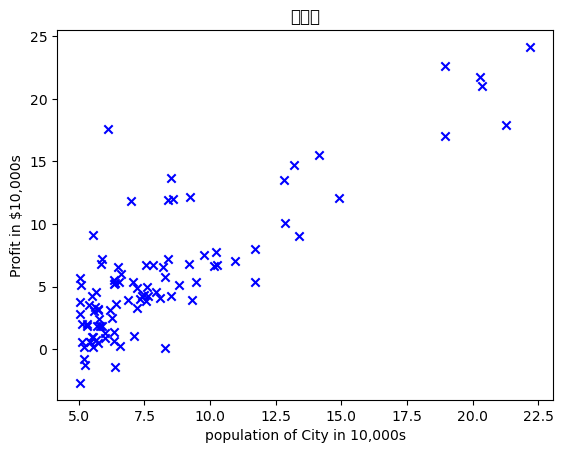

In [8]:
plt.scatter(x, y, marker = 'x', c = 'b')
plt.title('散点图')
plt.xlabel('population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.show()

D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 28070 (\N{CJK UNIFIED IDEOGRAPH-6DA6}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\Lib\site-packages\IPytho

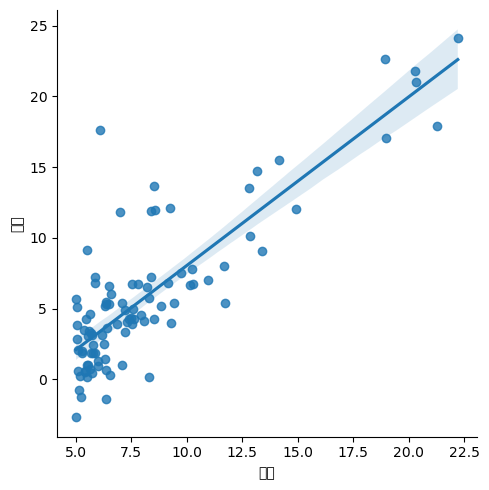

In [9]:
sns.lmplot(x = '人口',y = '利润' ,data = dt,fit_reg = True)
plt.show()

# 成本函数、梯度下降

In [10]:
X = np.hstack([np.ones((m, 1)), x.values.reshape(-1,1)])

In [11]:
y = y.values.reshape((97,1))

查看处理后的X和y：

In [12]:
print(X[:5],y[:5],sep = '\n')

[[1.     6.1101]
 [1.     5.5277]
 [1.     8.5186]
 [1.     7.0032]
 [1.     5.8598]]
[[17.592 ]
 [ 9.1302]
 [13.662 ]
 [11.854 ]
 [ 6.8233]]


In [13]:
theta0 = np.zeros((2,1))
theta0

array([[0.],
       [0.]])

In [14]:
def cost_function(X_train, y_train, theta):
    cost_sum = np.power(np.dot(X_train,theta)-y_train,2) #求出来是一列数组
    return np.sum(cost_sum)/(2*m)

In [15]:
cost_function(X, y, theta0)

np.float64(32.072733877455676)

In [16]:
def grandient_function(X, y, theta, alpha, cost_function,iters):
    n = theta.shape[0]
    temp = np.copy(theta)#创建副本
    cost = np.zeros(iters)
    for i in range(iters):
        errors = np.dot(X,theta)-y
        for j in range(n):
            temp[j,0] = temp[j,0]-alpha*(np.dot(errors.T,X[:,j].reshape([-1,1])))/m
        theta = temp #一次性更新所有参数
        cost[i] = cost_function(X, y, theta)
                                    
    return theta, cost     
        
    

In [17]:
alpha=0.01
iters=1500
theta = theta0

In [18]:
g, cost = grandient_function(X, y, theta, alpha, cost_function,iters)

C:\Users\86150\AppData\Local\Temp\ipykernel_20444\657085416.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  temp[j,0] = temp[j,0]-alpha*(np.dot(errors.T,X[:,j].reshape([-1,1])))/m


In [19]:
print(g)
print(cost)

[[-3.63029144]
 [ 1.16636235]]
[6.73719046 5.93159357 5.90115471 ... 4.48343473 4.48341145 4.48338826]


In [20]:
cost_function(X, y, g)

np.float64(4.483388256587726)

In [21]:
x = np.linspace(dt['人口'].min(),dt['利润'].max(),100)

In [22]:
x.shape

(100,)

In [138]:
f_wb = g[0,0] + g[1,0]*x

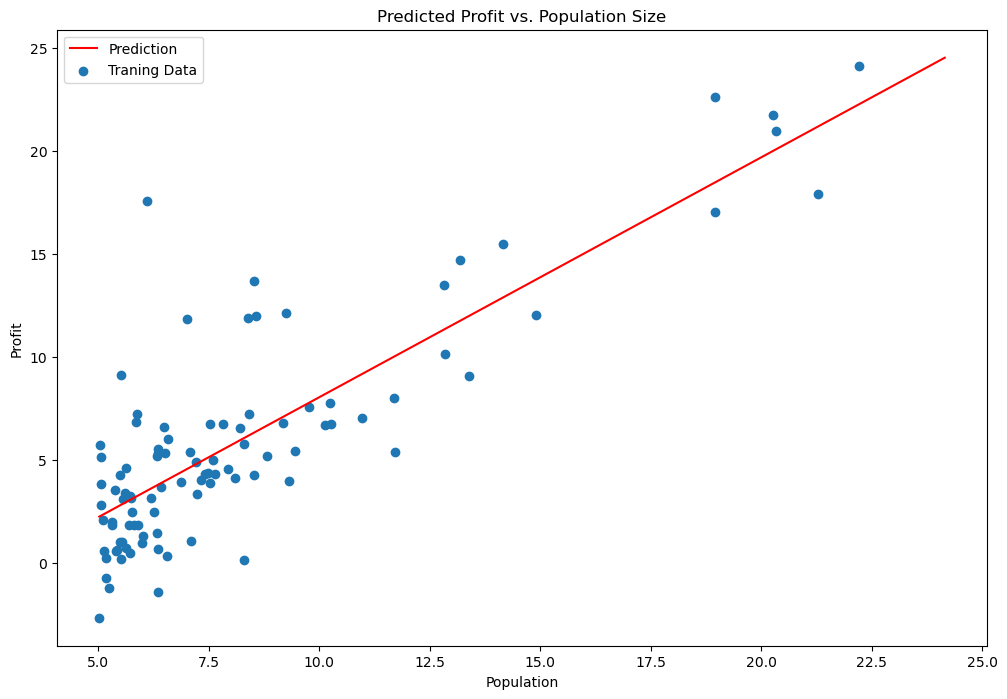

In [142]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x, f_wb,'r', label = 'Prediction')
ax.scatter(dt['人口'],dt['利润'],label='Traning Data')
ax.legend(loc=2)  #legend为显示图例函数，loc为设置图例显示的位置，loc=2即在左上方
ax.set_xlabel('Population')
ax.set_ylabel('Profit')
ax.set_title('Predicted Profit vs. Population Size')
plt.show()

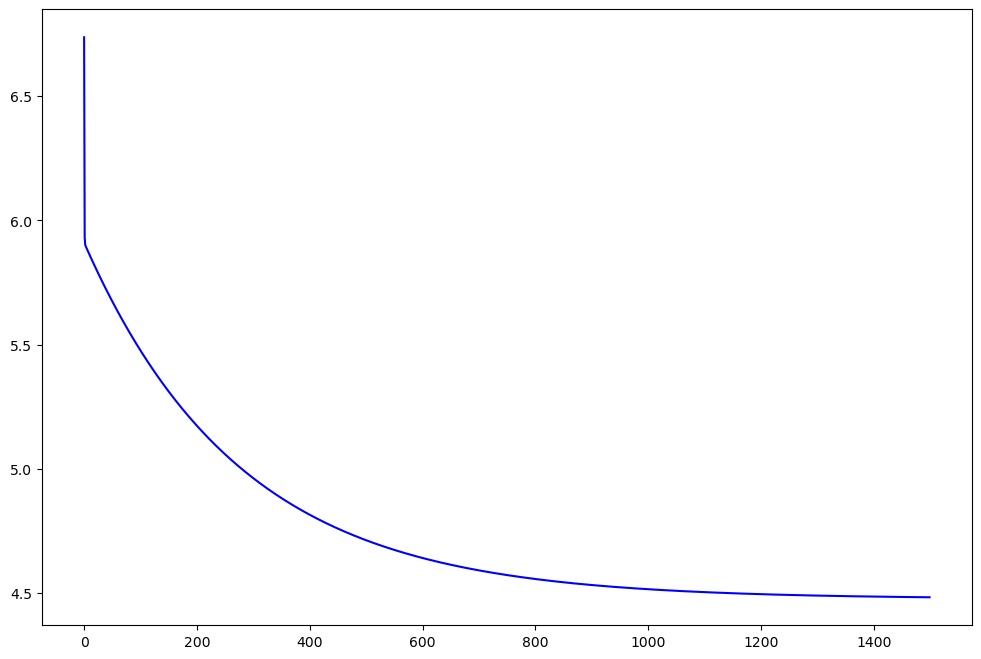

In [148]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(np.arange(iters), cost,'b')
plt.show()

# 多元线性回归

In [244]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import math

In [245]:
df = pd.read_csv('ex1data2.txt',header = None, names = ['Size','Number','price'])

In [246]:
df.head()

,Size,Number,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Size    47 non-null     int64
 1   Number  47 non-null     int64
 2   price   47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [248]:
X, y = df.iloc[:,:-1], df.price

In [249]:
m = len(X)

In [250]:
y = np.matrix(y).T

In [251]:
def zscore_function(x,y):
    u = np.mean(x, axis = 0)
    sigma = np.std(x, axis = 0)
    x_mean = x - u
    x_norm = x_mean/sigma
    y_norm = (y-np.mean(y))/np.std(y)

    return x_norm,y_norm

In [252]:
X_norm, y_norm = zscore_function(X,y)

In [253]:
x_norm = np.hstack([np.ones((m, 1)),X_norm])
cols = df.shape[1]
print(x_norm.shape)
cols
y.shape

(47, 3)


(47, 1)

In [257]:
X_norm[:5]

,Size,Number
0,0.131415,-0.226093
1,-0.509641,-0.226093
2,0.507909,-0.226093
3,-0.743677,-1.554392
4,1.271071,1.102205


In [258]:
y_norm[:5]

matrix([[ 0.48],
        [-0.08],
        [ 0.23],
        [-0.88],
        [ 1.61]])

In [275]:
def cost_function(x, y, theta):
    cost_i = np.dot(x,theta)-y
    return cost_i

In [276]:
def grandient_function(x, y, theta, alpha, iteration):
    n = cols
    
    for j in range(iteration):
        cos_i = cost_function(x, y, theta)
        
        theta = theta-alpha*(np.dot(x.T, cos_i))/m
        cost_sum = np.sum(np.square(cos_i))/(2*m)
        if j % math.ceil(iteration/10) == 0:
            print(f"迭代次数：{j}，当前系数B：{theta[1]}，总成本：{cost_sum}.")
        

    return theta, cost_sum
                    
        

In [277]:
theta2 = np.zeros((cols,1))
p = 0.01 
theta2

array([[0.],
       [0.],
       [0.]])

In [278]:
W, cost_sum = grandient_function(x_norm, y_norm, theta2, p, 1500)


迭代次数：0，当前系数B：[[0.01]]，总成本：0.5.
迭代次数：150，当前系数B：[[0.61]]，总成本：0.16171485631538343.
迭代次数：300，当前系数B：[[0.76]]，总成本：0.14041384329729917.
迭代次数：450，当前系数B：[[0.82]]，总成本：0.13535599467793766.
迭代次数：600，当前系数B：[[0.85]]，总成本：0.1340144304942597.
迭代次数：750，当前系数B：[[0.87]]，总成本：0.13365717814828126.
迭代次数：900，当前系数B：[[0.88]]，总成本：0.13356203083196752.
迭代次数：1050，当前系数B：[[0.88]]，总成本：0.13353669005427454.
迭代次数：1200，当前系数B：[[0.88]]，总成本：0.13352994099255228.
迭代次数：1350，当前系数B：[[0.88]]，总成本：0.1335281435009792.


In [279]:
print(W, cost_sum)

[[-0.  ]
 [ 0.88]
 [-0.05]] 0.13352766631091267
